In [3]:
import numpy as np 
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science', 'no-latex', 'notebook'])

In [4]:
def _eye(d):
    return sp.eye(d, format='csr')

def _destroy(d):
    data = np.sqrt(np.arange(1, d, dtype=float))
    return sp.diags(data, 1, shape=(d, d), format='csr')

def _num(d):
    return sp.diags(np.arange(d, dtype=float), 0, format='csr')

# N celdas unidad
def single_electron_ssh_matrix(N, t1, t2):
    diag = [t1 if j%2 == 0 else t2 for j in range(2*N)]
    h = sp.diags(diagonals = (diag[:-1]), offsets= 1, shape=(2*N, 2*N), format = 'csr')
    return h + np.conj(h).T

def ssh_cavity(unit_cells, fock_photon, t1, t2, g, omega_c):
    H_ph = omega_c * _num(fock_photon)
    x_ph = _destroy(fock_photon) + _destroy(fock_photon).conj().T
    eye_photon = _eye(fock_photon)
    eye_electron = sp.eye(2 * unit_cells, format = 'csr')
    H0 = single_electron_ssh_matrix(unit_cells, t1, t2)
    H1 = single_electron_ssh_matrix(unit_cells, t1, -t2)
    return sp.kron(H_ph, eye_electron, format = 'csr') + sp.kron(eye_photon, H0, format = 'csr') + g * sp.kron(x_ph, H1, format = 'csr')

In [ ]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0)
omega_c_values = [0.5, 2.0, 5.0, 15.0]
g = 0.2

H_array = [[ssh_cavity(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array = [[eigsh(H, 4*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

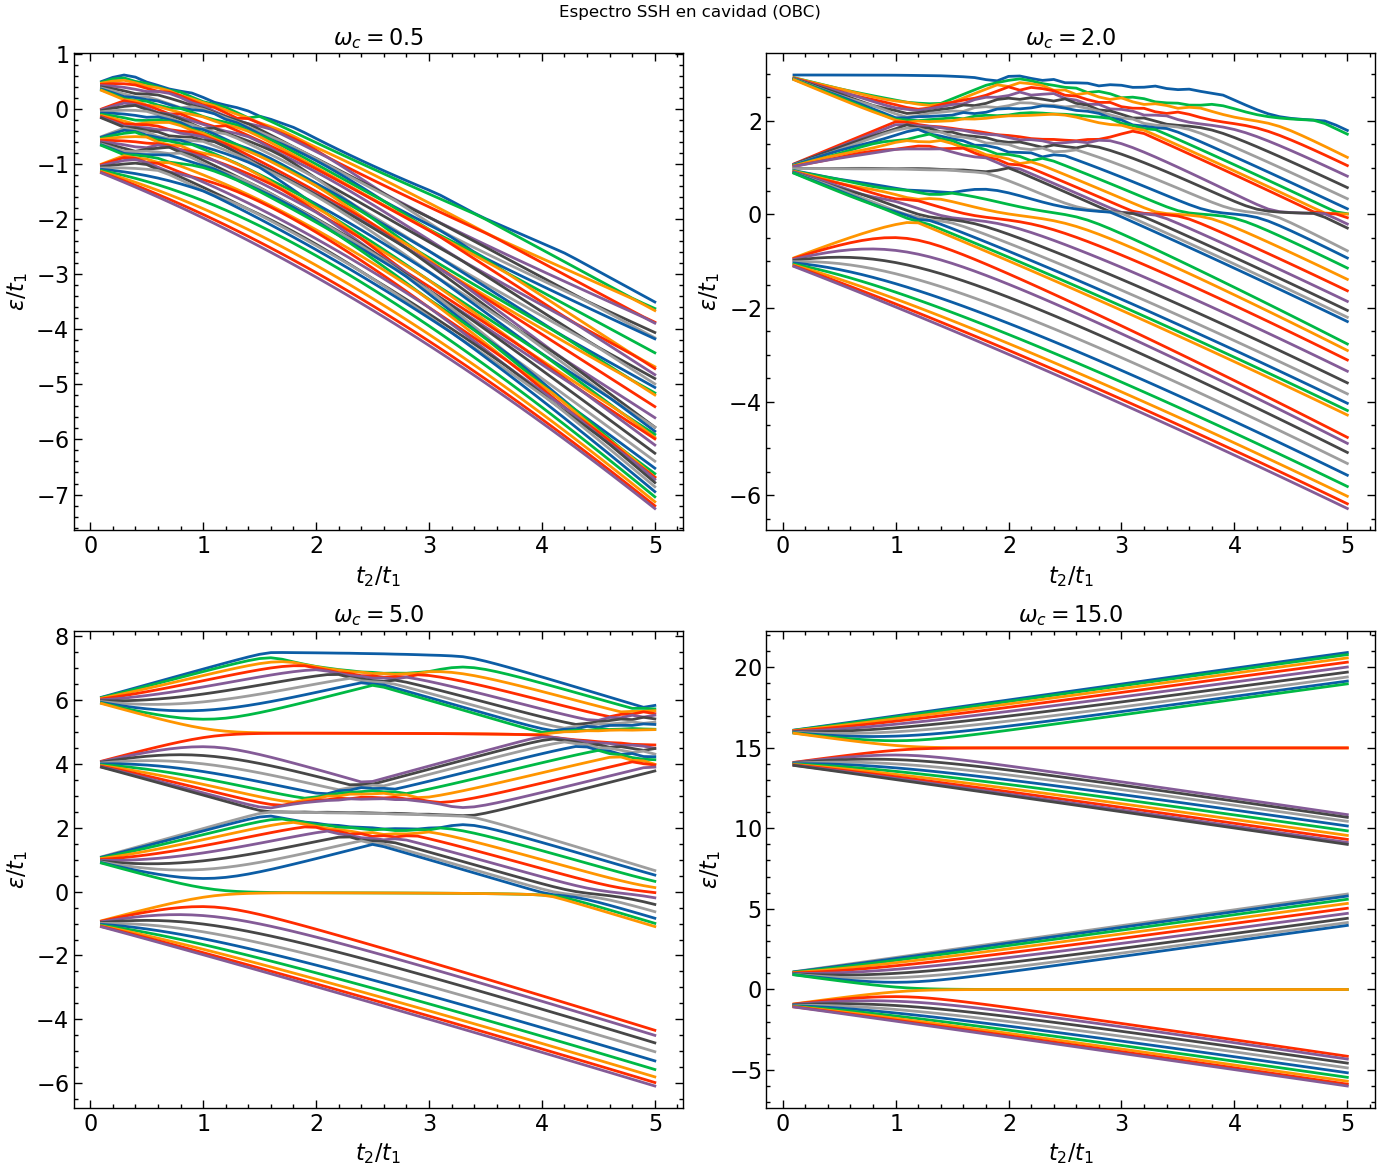

In [27]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 12))

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array):
    ax.set_title(rf'$\omega_c = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    
fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()


In [5]:
def periodic_ssh(N, t1, t2):
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    delta_0 = t1 + t2 * np.exp(-1.0j * k_values)
    aux_diag = np.empty(shape = 2*N, dtype = complex)
    aux_diag[0::2] = delta_0
    aux_diag[1::2] = 0.0
    h = sp.diags(diagonals = (aux_diag[:-1]), offsets= 1, shape=(2*N, 2*N), format = 'csr')
    return h + np.conj(h).T

In [6]:
def periodic_ssh_cavity(unit_cells, fock_photon, t1, t2, g, omega_c):
    H_ph = omega_c * _num(fock_photon)
    x_ph = _destroy(fock_photon) + _destroy(fock_photon).conj().T
    eye_photon = _eye(fock_photon)
    eye_electron = sp.eye(2 * unit_cells, format = 'csr')
    H0 = periodic_ssh(unit_cells, t1, t2)
    H1 = periodic_ssh(unit_cells, t1, -t2)
    return sp.kron(H_ph, eye_electron, format = 'csr') + sp.kron(eye_photon, H0, format = 'csr') + g * sp.kron(x_ph, H1, format = 'csr')

In [28]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0, 100)
omega_c = 2.0
g = 0.2


H_array = [[periodic_ssh_cavity(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array = [[eigsh(H, 4*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

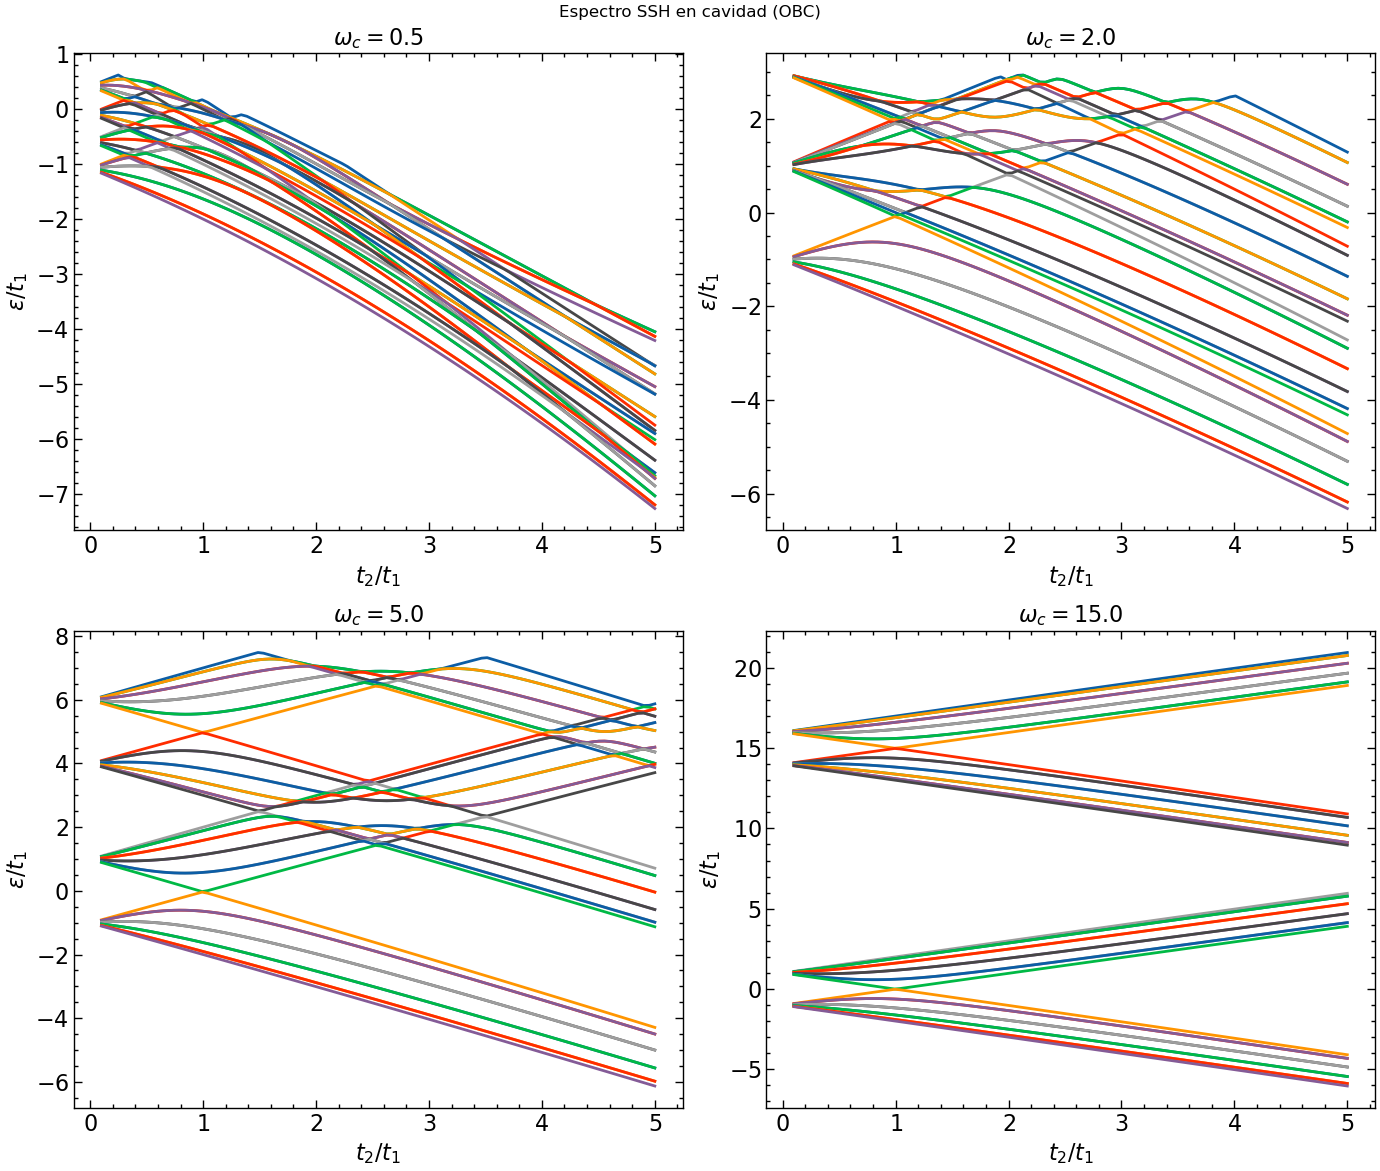

In [29]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 12))

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array):
    ax.set_title(rf'$\omega_c = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    
fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()


In [7]:
def dicke_model_ssh(unit_cells, fock_photon, t1, t2, g, omega_c):
    H_ph = omega_c * _num(fock_photon)
    x_ph = _destroy(fock_photon) + _destroy(fock_photon).conj().T
    eye_photon = _eye(fock_photon)
    eye_electron = sp.eye(2 * unit_cells, format = 'csr')
    k_values = np.linspace(-np.pi, np.pi, unit_cells, endpoint= False)
    delta_0 = t1 + t2 * np.exp(-1.0j * k_values)
    delta_x = (t1**2 - t2**2) / np.abs(delta_0)
    delta_y = 2 * t1 * t2 * np.sin(k_values) / np.abs(delta_0)
    energy_correction = -(g * delta_x)**2 / omega_c
    
    diag_0 = np.empty(shape = 2*N, dtype = complex)
    diag_1 = np.empty(shape = 2*N, dtype = complex)
    
    diag_0[0::2] = np.abs(delta_0) + energy_correction
    diag_0[1::2] = -np.abs(delta_0) + energy_correction
    
    diag_1[0::2] = 1.0j * delta_y
    diag_1[1::2] = 0.0
    
    H0 = sp.diags(diagonals = diag_0, offsets= 0, shape=(2*N, 2*N), format = 'csr')
    H1_aux = sp.diags(diagonals = diag_1 , offsets= 1, shape=(2*N, 2*N), format = 'csr')
    H1 = H1_aux + H1_aux.conj().T
    
    return sp.kron(H_ph, eye_electron, format = 'csr') + sp.kron(eye_photon, H0, format = 'csr') + g * sp.kron(x_ph, H1, format = 'csr')
    

In [40]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0, 100)
omega_c = 2.0
g = 0.2


H_array = [[periodic_ssh_cavity(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array_full = [[eigsh(H, 6*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

H_array = [[dicke_model_ssh(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array_effective = [[eigsh(H, 6*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

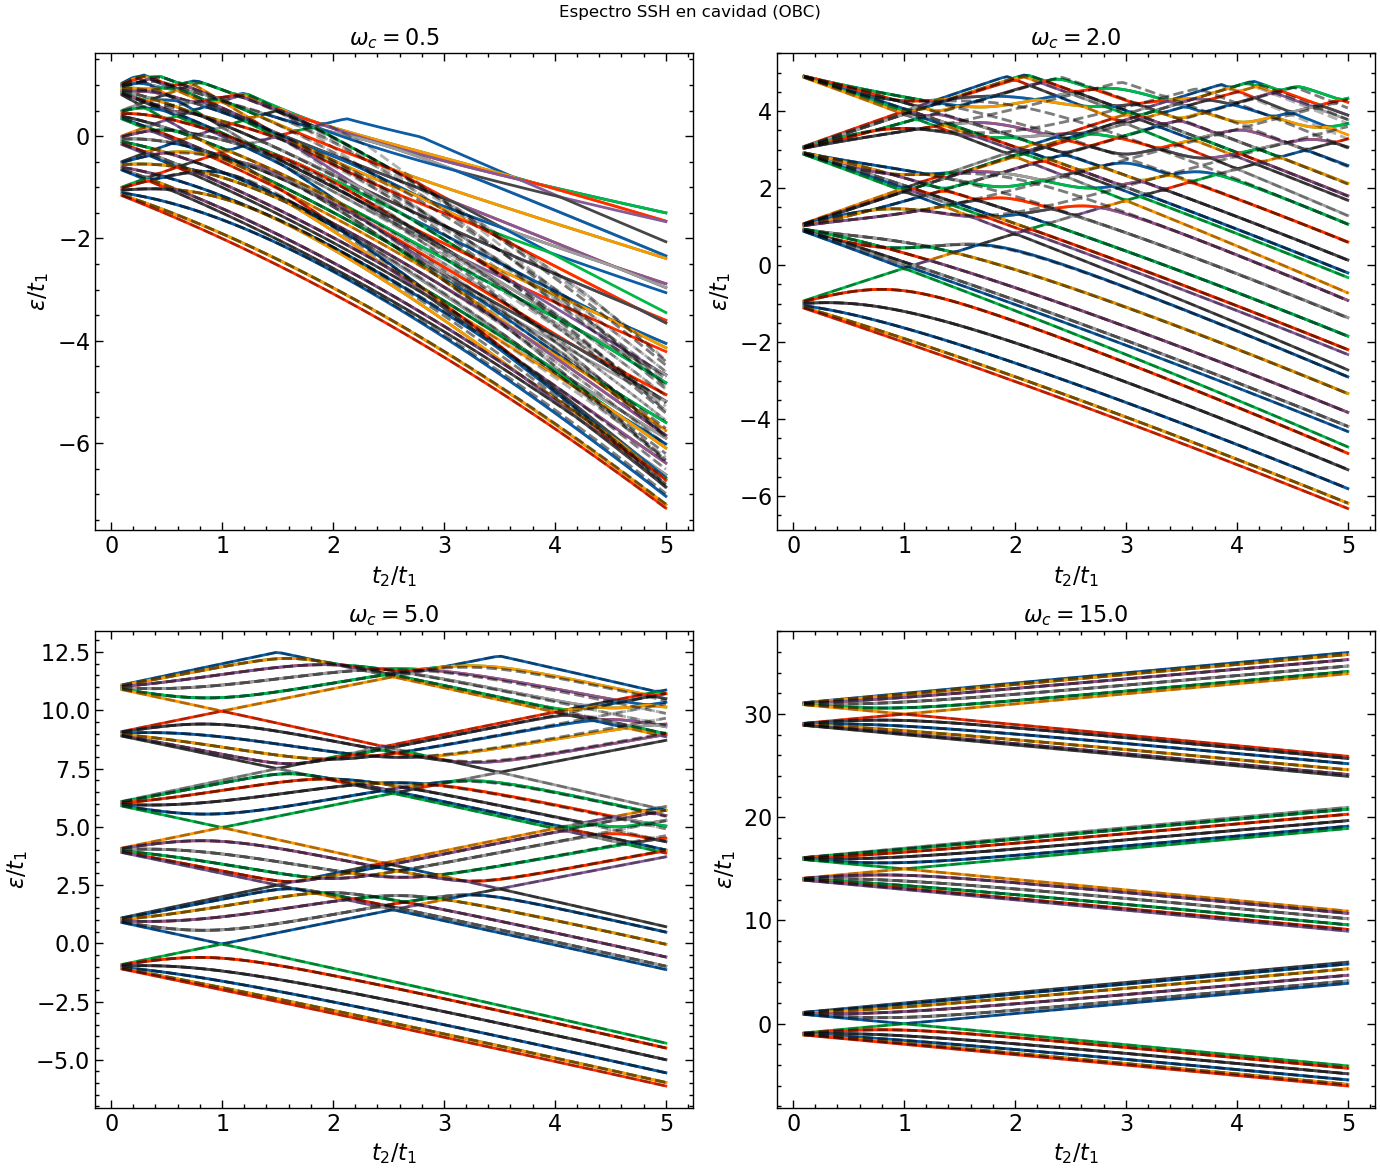

In [41]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 12))

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array_full):
    ax.set_title(rf'$\omega_c = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array_effective):
    ax.set_title(rf'$\omega_c = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c, color = 'black', linestyle = 'dashed', alpha = 0.3)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    
fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()

In [39]:
def tavis_cummings_ssh(unit_cells, fock_photon, t1, t2, g, omega_c):
    H_ph = omega_c * _num(fock_photon)
    a_ph = _destroy(fock_photon)
    eye_photon = _eye(fock_photon)
    eye_electron = sp.eye(2 * unit_cells, format = 'csr')
    k_values = np.linspace(-np.pi, np.pi, unit_cells, endpoint= False)
    delta_0 = t1 + t2 * np.exp(-1.0j * k_values)
    delta_x = (t1**2 - t2**2) / np.abs(delta_0)
    delta_y = 2 * t1 * t2 * np.sin(k_values) / np.abs(delta_0)
    energy_correction = -(g * delta_x)**2 / omega_c
    
    diag_0 = np.empty(shape = 2*N, dtype = complex)
    diag_1 = np.empty(shape = 2*N, dtype = complex)
    
    diag_0[0::2] = np.abs(delta_0) + energy_correction
    diag_0[1::2] = -np.abs(delta_0) + energy_correction
    
    diag_1[0::2] = 1.0j * delta_y
    diag_1[1::2] = 0.0
    
    H0 = sp.diags(diagonals = diag_0, offsets= 0, shape=(2*N, 2*N), format = 'csr')
    H1_aux = sp.diags(diagonals = diag_1 , offsets= 1, shape=(2*N, 2*N), format = 'csr')
 
    return sp.kron(H_ph, eye_electron, format = 'csr') + sp.kron(eye_photon, H0, format = 'csr') + g * (sp.kron(a_ph, H1_aux, format = 'csr') + sp.kron(a_ph.conj().T, H1_aux.conj().T, format = 'csr'))
    

# matrices densidad

def partial_trace(psi, n, m, keep='A'):
    M = psi.reshape(n, m)
    
    if keep == 'A':
        return M @ M.conj().T   # shape (n, n)
    else:
        return M.conj().T @ M   # shape (m, m)

In [17]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0, 100)
omega_c_values = [0.5, 2.0, 5.0, 15.0]
g = 0.2


H_array = [[tavis_cummings_ssh(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array_tavis = [[eigsh(H, 6*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

H_array = [[dicke_model_ssh(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
energy_array_dicke = [[eigsh(H, 6*N, which = 'SA', return_eigenvectors = False) for H in H_omega] for H_omega in H_array]

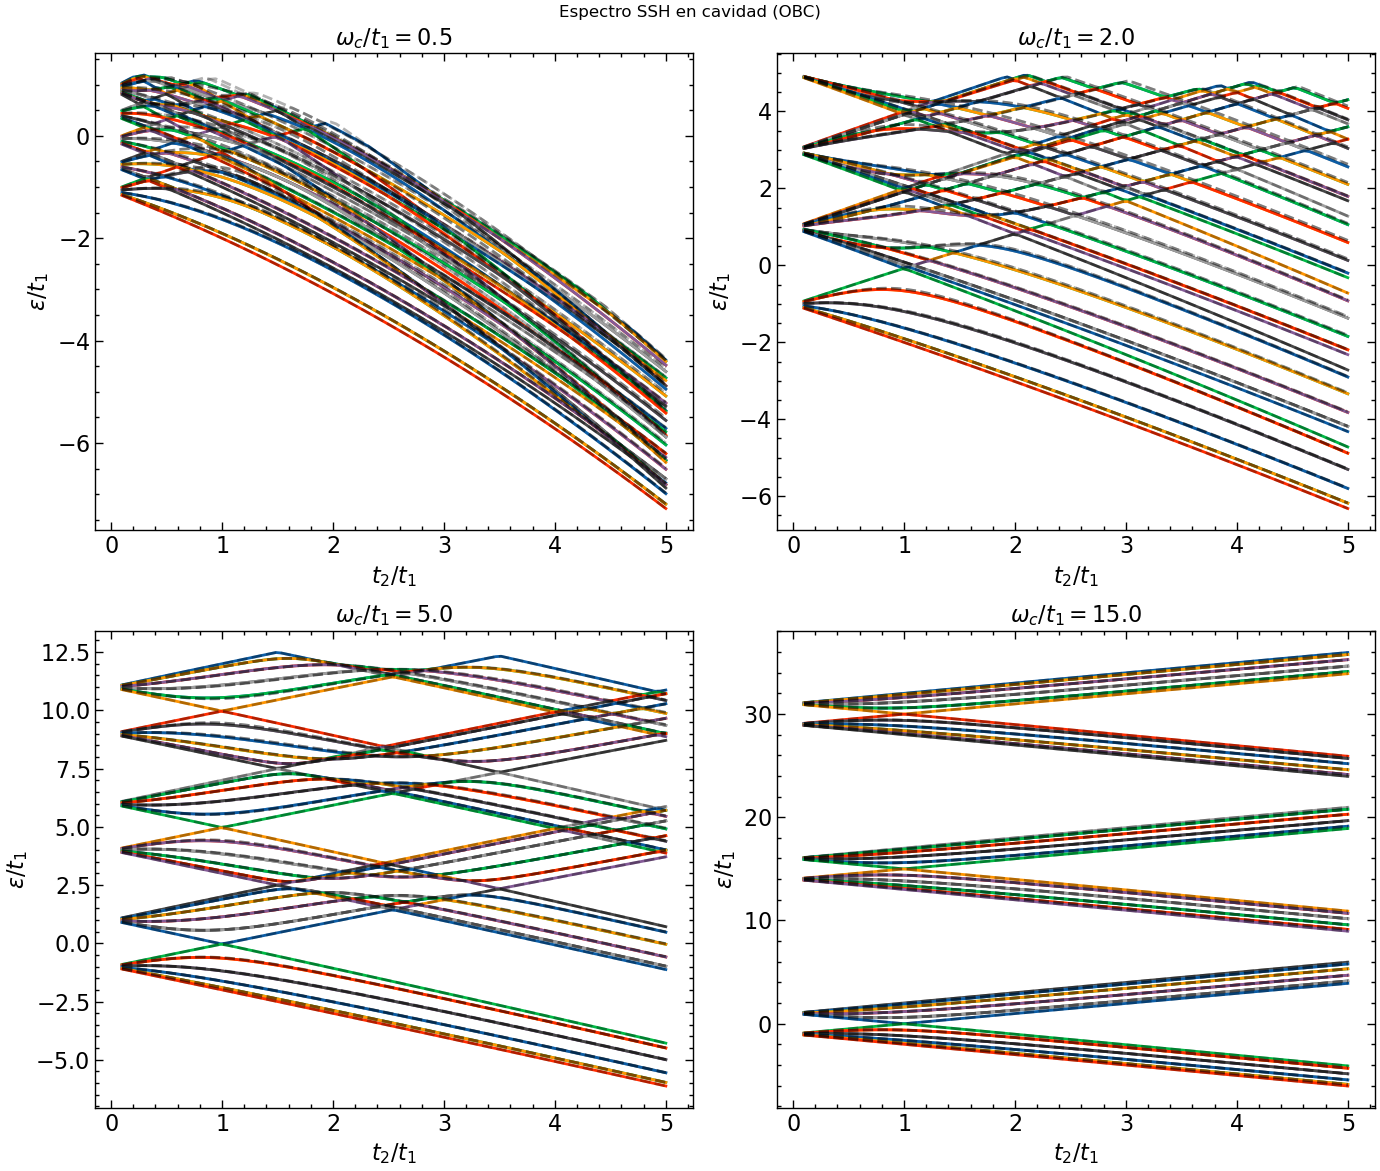

In [19]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14, 12))

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array_dicke):
    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')

for omega_c, ax, energy_omega_c in zip(omega_c_values, axes.flatten(), energy_array_tavis):
    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    ax.plot(t2_values, energy_omega_c, color = 'black', linestyle = 'dashed', alpha = 0.3)
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    
fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()

In [ ]:
def fourier_modes(N, t1, t2, g, omega_c, delta):
    k_values = np.linspace(-np.pi, np.pi, N, endpoint= False)
    delta_0 = t1 + t2 * np.exp(-1.0j * k_values)
    delta_x = (t1**2 - t2**2) / np.abs(delta_0)
    delta_y = 2 * t1 * t2 * np.sin(k_values) / np.abs(delta_0)
    energy_correction = -(g * delta_x)**2 / omega_c
    exponentials = np.exp(1.0j * delta * k_values)
    return np.sum(energy_correction * exponentials)

In [37]:
delta_values = np.linspace(0.0, N)
discrete_delta_values = np.arange(0.0, N+1, 1.0, dtype = int)
fourier = [fourier_modes(N, t1, t2_values[20], g, omega_c, delta) for delta in delta_values]
discrete_fourier = [fourier_modes(N, t1, t2_values[20], g, omega_c, delta) for delta in discrete_delta_values] 

/home/ruiz/miniconda3/envs/quantum/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/ruiz/miniconda3/envs/quantum/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/home/ruiz/miniconda3/envs/quantum/lib/python3.14/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


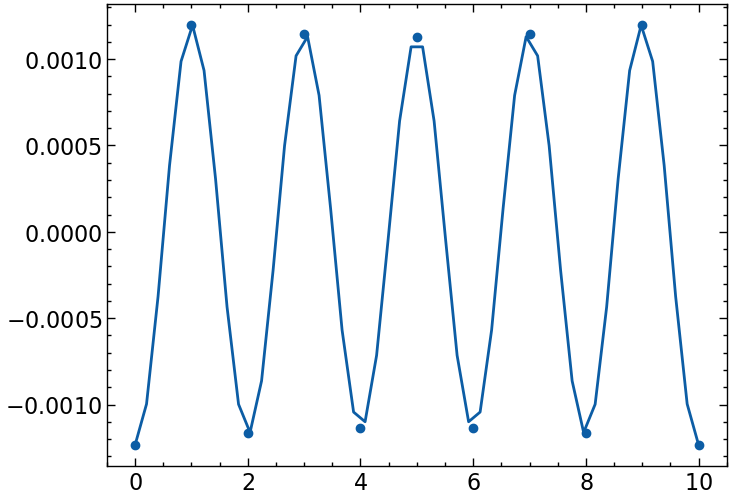

In [38]:
plt.plot(delta_values, np.array(fourier)/(N * 1.0))
plt.scatter(discrete_delta_values, np.array(discrete_fourier)/(N * 1.0))

In [ ]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0)
omega_c_values = [0.5, 2.0, 5.0, 15.0]
g = 0.2

H_array = [[ssh_cavity(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
result_array = [[eigsh(H, 4*N, which='SA', return_eigenvectors=True) 
                 for H in H_omega] 
                for H_omega in H_array]

energy_array = [[res[0] for res in row] for row in result_array]
state_array  = [[res[1] for res in row] for row in result_array]
photon_dm_array = [
    [
        [partial_trace(np.array(state_array[i][j][:, k]), N_photon, 2*N, keep='A') 
         for k in range(4*N)]          # loop over eigenstates
        for j in range(len(t2_values)) # loop over t2
    ]
    for i in range(len(omega_c_values))# loop over omega_c
]

purity_array = [
    [
        [np.einsum('ij,ji->', dm, dm).real 
         for dm in dm_t2]
        for dm_t2 in dm_omega
    ]
    for dm_omega in photon_dm_array
]

purity_array = np.array(purity_array) 

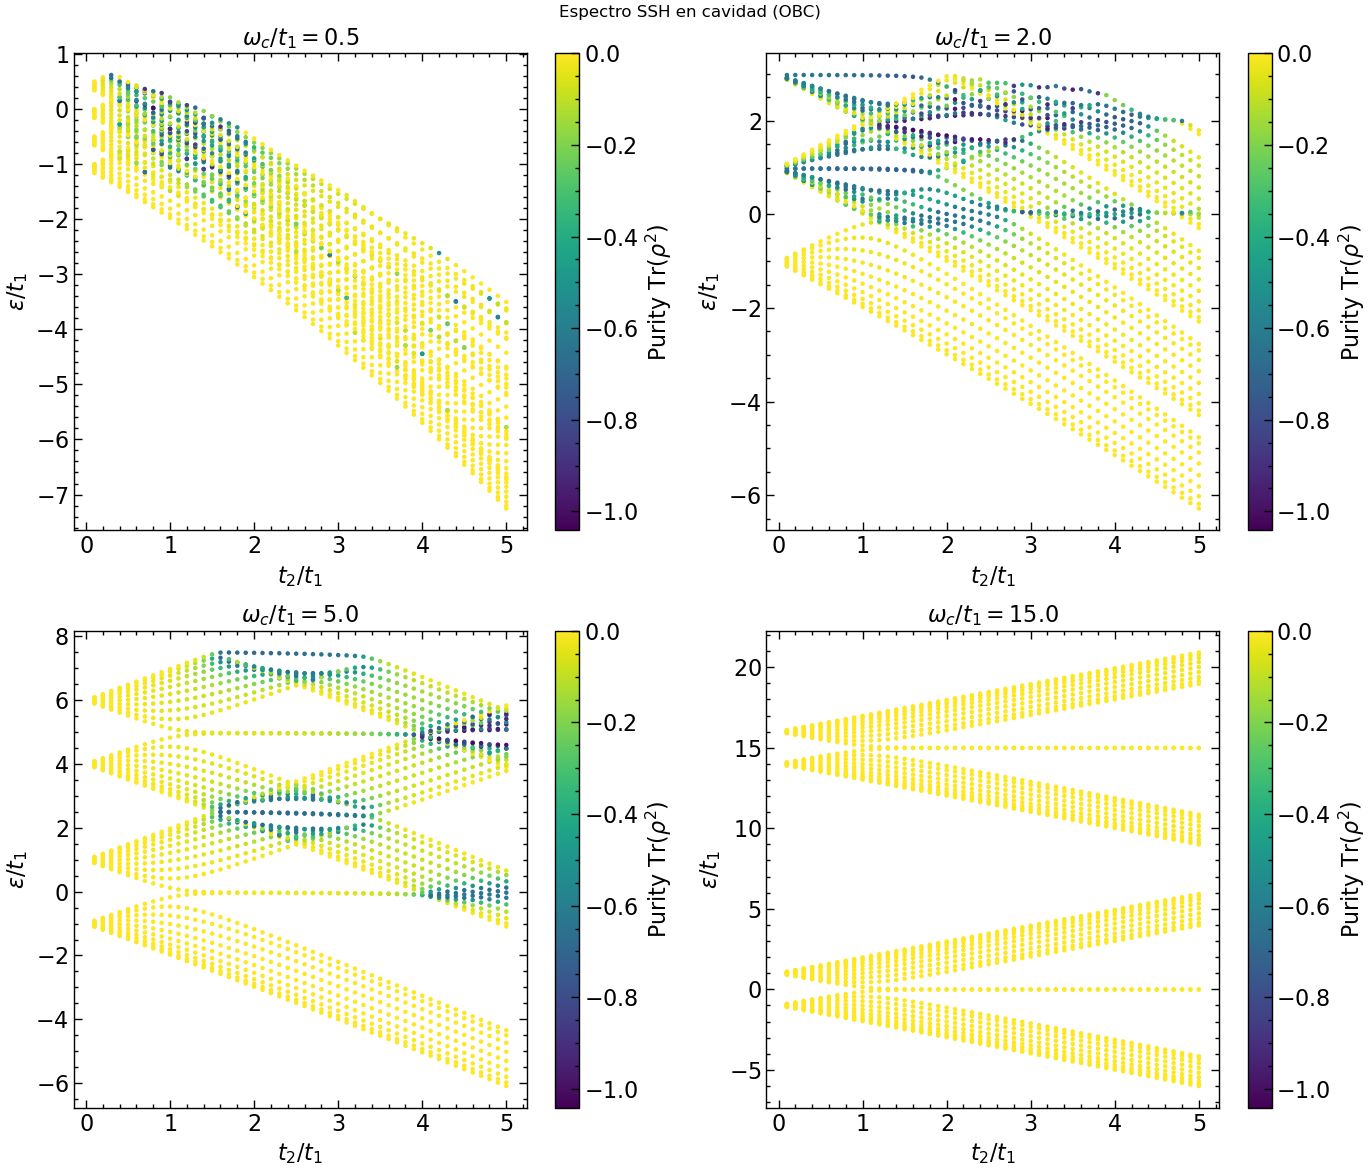

In [64]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

for i, (omega_c, ax, energy_omega_c) in enumerate(zip(omega_c_values, axes.flatten(), energy_array)):
    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    
    purity_omega_c = np.log(purity_array[i])  # shape: (n_t2, n_states)
    
    for k in range(4 * N):
        energies_k = [energy_omega_c[j][k] for j in range(len(t2_values))]
        purities_k = purity_omega_c[:, k]  # purity along t2 for state k
        
        sc = ax.scatter(t2_values, energies_k, c=purities_k, 
                        cmap='viridis', vmin=np.log(np.min(purity_array)), vmax=0.0, s=5)
    
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(r'Purity $\mathrm{Tr}(\rho^2)$')
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')

fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()
plt.show()

In [ ]:
N = 10
N_photon = 8
t1 = 1.0
t2_values = np.linspace(0.1, 5.0)
omega_c_values = [0.5, 2.0, 5.0, 15.0]
g = 0.2

H_array = [[ssh_cavity(N, N_photon, t1, t2, g, omega_c) for t2 in t2_values] for omega_c in omega_c_values]
result_array = [[eigsh(H, 4*N, which='SA', return_eigenvectors=True) 
                 for H in H_omega] 
                for H_omega in H_array]

energy_array = [[res[0] for res in row] for row in result_array]
state_array  = [[res[1] for res in row] for row in result_array]
photon_dm_array = [
    [
        [partial_trace(np.array(state_array[i][j][:, k]), N_photon, 2*N, keep='A') 
         for k in range(4*N)]          # loop over eigenstates
        for j in range(len(t2_values)) # loop over t2
    ]
    for i in range(len(omega_c_values))# loop over omega_c
]

purity_array = [
    [
        [np.einsum('ij,ji->', dm, dm).real 
         for dm in dm_t2]
        for dm_t2 in dm_omega
    ]
    for dm_omega in photon_dm_array
]

purity_array = np.array(purity_array) 

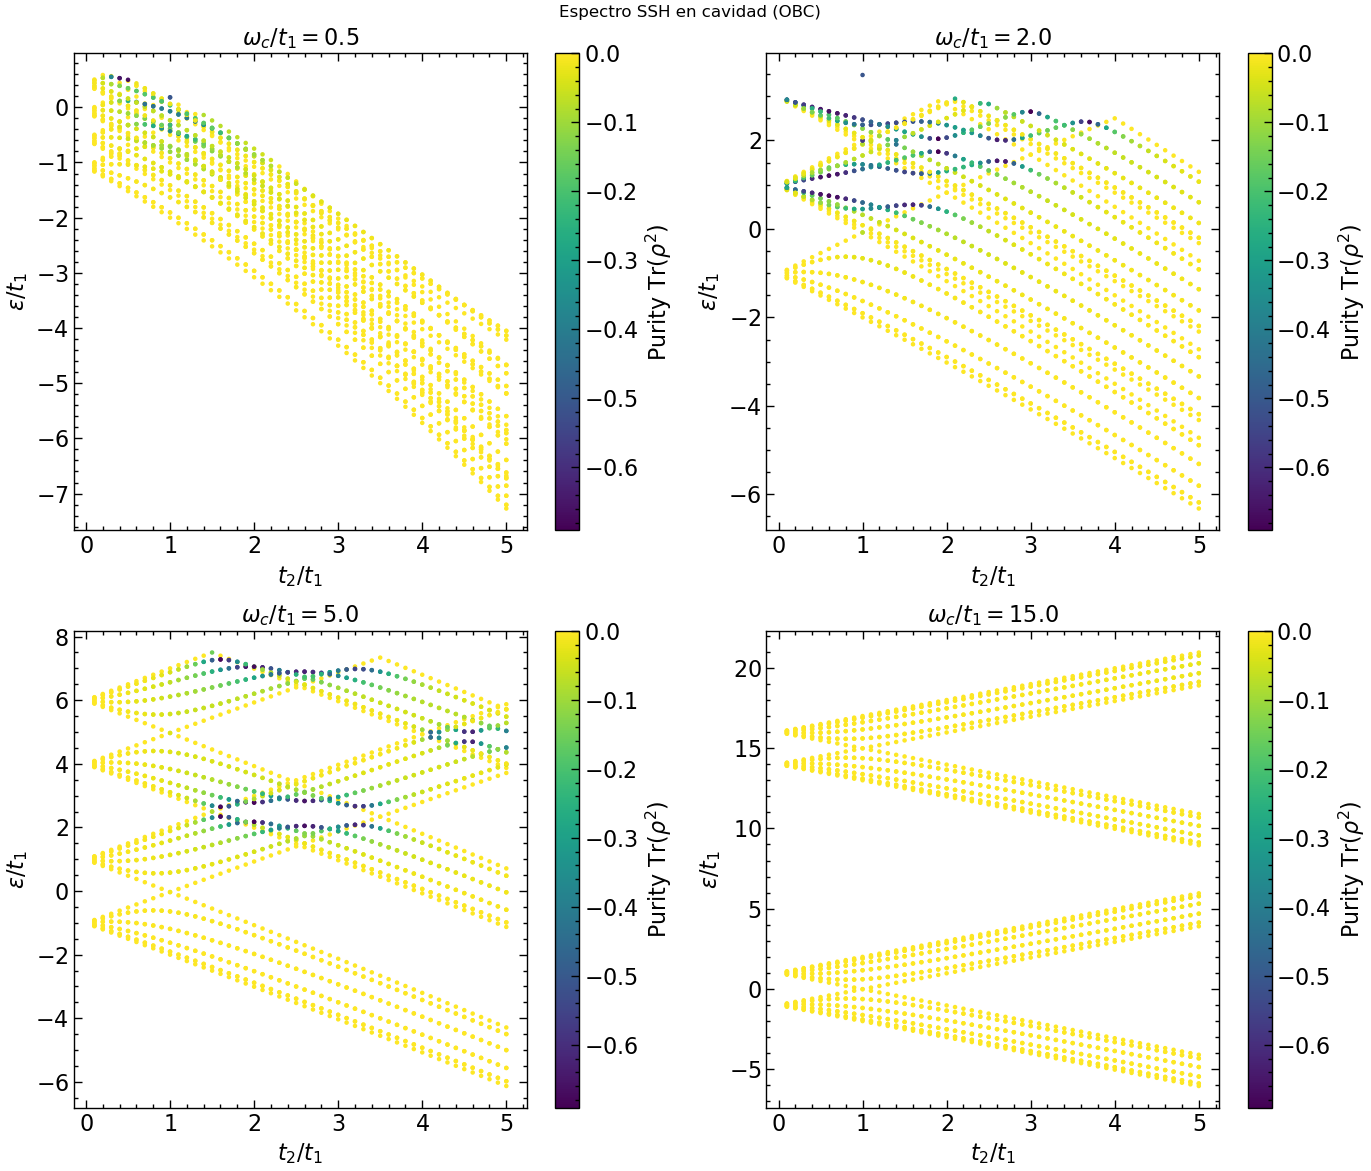

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))

for i, (omega_c, ax, energy_omega_c) in enumerate(zip(omega_c_values, axes.flatten(), energy_array)):
    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    
    purity_omega_c = np.log(purity_array[i])  # shape: (n_t2, n_states)
    
    for k in range(4 * N):
        energies_k = [energy_omega_c[j][k] for j in range(len(t2_values))]
        purities_k = purity_omega_c[:, k]  # purity along t2 for state k
        
        sc = ax.scatter(t2_values, energies_k, c=purities_k, 
                        cmap='viridis', vmin=np.log(np.min(purity_array)), vmax=0.0, s=5)
    
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(r'Purity $\mathrm{Tr}(\rho^2)$')
    ax.set_xlabel(r'$t_2 / t_1$')
    ax.set_ylabel(r'$\epsilon / t_1$')

fig.suptitle('Espectro SSH en cavidad (OBC)')
fig.tight_layout()
plt.show()

In [147]:
from scipy.sparse import csr_matrix

I2 = csr_matrix(np.eye(2, dtype=complex))
sx = csr_matrix([[0, 1], [1, 0]], dtype=complex)
sy = csr_matrix([[0, -1j], [1j, 0]], dtype=complex)
sz = csr_matrix([[1, 0], [0, -1]], dtype=complex)
s_minus = csr_matrix([[0, 0], [1, 0]], dtype=complex)
s_plus = csr_matrix([[0, 1], [0, 0]], dtype=complex)

def k_block_ssh(unit_cells, t1, t2, k_index):
    k = np.linspace(-np.pi, np.pi, unit_cells, endpoint= False)[k_index]
    return (t1 + t2) * np.cos(k/2) * sx + (t1-t2) * np.sin(k/2) * sy
    
def k_block_ssh_cavity(unit_cells, fock_photon, t1, t2, g, omega_c, k_index):
    H_ph = omega_c * _num(fock_photon)
    x_ph = _destroy(fock_photon) + _destroy(fock_photon).conj().T
    eye_photon = _eye(fock_photon)
    H0_block = k_block_ssh(unit_cells, t1, t2, k_index)
    H1_block = k_block_ssh(unit_cells, t1, -t2, k_index)
        
    return sp.kron(H_ph, I2, format = 'csr') + sp.kron(eye_photon, H0_block, format = 'csr') + g * sp.kron(x_ph, H1_block, format = 'csr')

In [102]:
from matplotlib.collections import LineCollection

In [176]:
N = 100
N_photon = 8
t1 = 1.0
omega_c_values = [0.5, 2.0, 4.0, 15.0]
g = 0.2
k_values = np.linspace(-np.pi, np.pi, N, endpoint=False)
t2 = 2.0
n_bands = 6

H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g, omega_c, k_index) 
            for k_index in range(N)]
           for omega_c in omega_c_values]

result_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=True) 
                 for H in H_omega]
                for H_omega in H_array]

energy_array = [[res[0] for res in row] for row in result_array]
state_array  = [[res[1] for res in row] for row in result_array]

photon_dm_array = [
    [
        [partial_trace(np.array(state_array[i][j][:, k]), N_photon, 2, keep='A')  # fix: 2 not 2*N
         for k in range(n_bands)]
        for j in range(len(k_values))
    ]
    for i in range(len(omega_c_values))
]

purity_array = np.array([
    [
        [np.einsum('ij,ji->', dm, dm).real for dm in dm_k]
        for dm_k in dm_omega
    ]
    for dm_omega in photon_dm_array
])  # shape: (n_omega, n_k, n_bands)

bare_H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g=0, omega_c=omega_c, k_index=k_index)
                 for k_index in range(N)]
                for omega_c in omega_c_values]

bare_energy_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=False)
                      for H in H_omega]
                     for H_omega in bare_H_array]

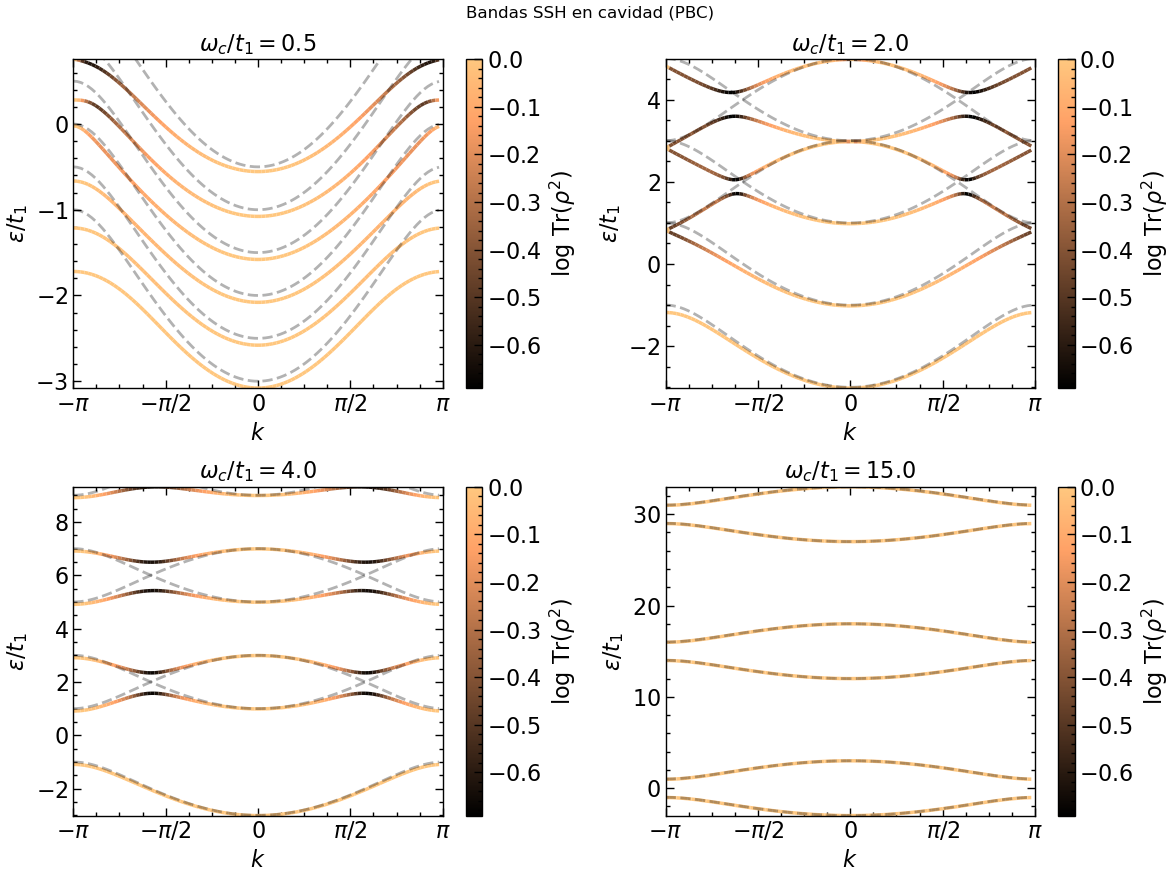

In [177]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
vmin = np.log(np.min(purity_array))

for i, (omega_c, ax) in enumerate(zip(omega_c_values, axes.flatten())):
    
    purity_omega_c = np.log(purity_array[i])
    energies_omega_c = np.array(energy_array[i])

    sorted_energies = np.zeros_like(energies_omega_c)
    sorted_purities = np.zeros_like(purity_omega_c)
    sorted_energies[0] = energies_omega_c[0]
    sorted_purities[0] = purity_omega_c[0]

    for ik in range(1, len(k_values)):
        prev = sorted_energies[ik - 1]
        curr = energies_omega_c[ik]
        order = []
        available = list(range(n_bands))
        for b in range(n_bands):
            diffs = [abs(curr[a] - prev[b]) for a in available]
            best = available[np.argmin(diffs)]
            order.append(best)
            available.remove(best)
        sorted_energies[ik] = curr[order]
        sorted_purities[ik] = purity_omega_c[ik][order]

    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    norm = plt.Normalize(vmin=vmin, vmax=0.0)
    cmap = plt.cm.copper

    for band in range(n_bands):
        points = np.array([k_values, sorted_energies[:, band]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5)
        lc.set_array(sorted_purities[:, band])
        ax.add_collection(lc)

    ax.set_xlim(k_values.min(), k_values.max())
    ax.set_ylim(sorted_energies.min(), sorted_energies.max())
    ax.plot(k_values, bare_energy_array[i], linestyle = 'dashed', color = 'black', alpha = 0.3)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label(r'$\log\,\mathrm{Tr}(\rho^2)$')
    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

fig.suptitle('Bandas SSH en cavidad (PBC)')
fig.tight_layout()
plt.show()

In [165]:
def k_block_ssh_cavity_tc(unit_cells, fock_photon, t1, t2, g, omega_c, k_index):
    H_ph = omega_c * _num(fock_photon)
    a_ph = _destroy(fock_photon)
    eye_photon = _eye(fock_photon)
    k_value = np.linspace(-np.pi, np.pi, unit_cells, endpoint= False)[k_index]
    delta_0 = t1 + t2 * np.exp(-1.0j * k_value)
    delta_x = (t1**2 - t2**2) / np.abs(delta_0)
    delta_y = 2 * t1 * t2 * np.sin(k_value) / np.abs(delta_0)
    energy_correction = -(g * delta_x)**2 / omega_c
    H0 = np.abs(delta_0) * sz + energy_correction * I2
    H1_aux = s_plus * delta_y * 1.0j
    
    return sp.kron(H_ph, I2, format = 'csr') + sp.kron(eye_photon, H0, format = 'csr') + g * (sp.kron(a_ph, H1_aux, format = 'csr') + sp.kron(a_ph.conj().T, H1_aux.conj().T, format = 'csr'))
    

In [178]:
N = 100
N_photon = 8
t1 = 1.0
omega_c_values = [0.5, 2.0, 4.0, 15.0]
g = 0.2
k_values = np.linspace(-np.pi, np.pi, N, endpoint=False)
t2 = 2.0
n_bands = 6

H_array = [[k_block_ssh_cavity_tc(N, N_photon, t1, t2, g, omega_c, k_index) 
            for k_index in range(N)]
           for omega_c in omega_c_values]

result_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=True) 
                 for H in H_omega]
                for H_omega in H_array]

energy_array = [[res[0] for res in row] for row in result_array]
state_array  = [[res[1] for res in row] for row in result_array]

photon_dm_array = [
    [
        [partial_trace(np.array(state_array[i][j][:, k]), N_photon, 2, keep='A')  # fix: 2 not 2*N
         for k in range(n_bands)]
        for j in range(len(k_values))
    ]
    for i in range(len(omega_c_values))
]

purity_array = np.array([
    [
        [np.einsum('ij,ji->', dm, dm).real for dm in dm_k]
        for dm_k in dm_omega
    ]
    for dm_omega in photon_dm_array
])  # shape: (n_omega, n_k, n_bands)

bare_H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g, omega_c, k_index) 
            for k_index in range(N)]
           for omega_c in omega_c_values]

bare_energy_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=False) 
                 for H in H_omega]
                for H_omega in bare_H_array]


# bare_H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g=0, omega_c=omega_c, k_index=k_index)
#                  for k_index in range(N)]
#                 for omega_c in omega_c_values]

# bare_energy_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=False)
#                       for H in H_omega]
#                      for H_omega in bare_H_array]

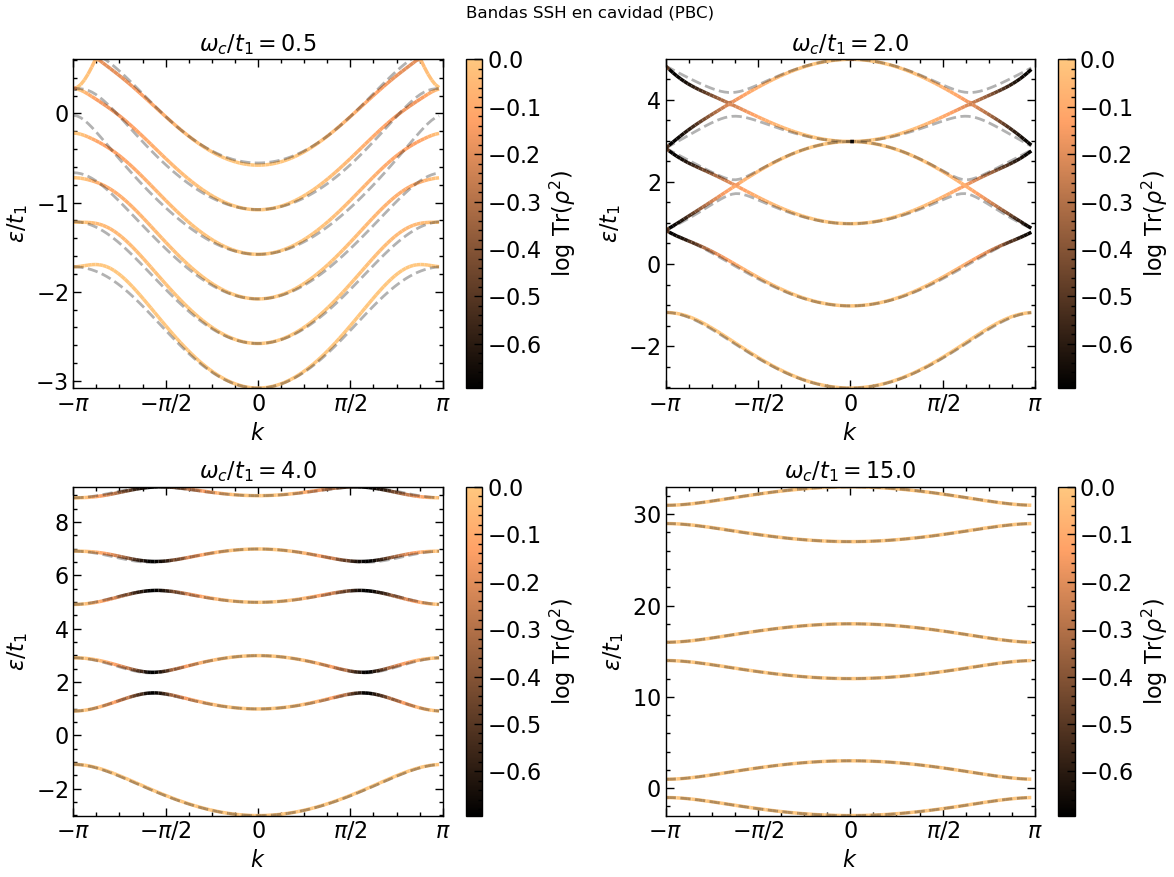

In [179]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
vmin = np.log(np.min(purity_array))

for i, (omega_c, ax) in enumerate(zip(omega_c_values, axes.flatten())):
    
    purity_omega_c = np.log(purity_array[i])
    energies_omega_c = np.array(energy_array[i])

    sorted_energies = np.zeros_like(energies_omega_c)
    sorted_purities = np.zeros_like(purity_omega_c)
    sorted_energies[0] = energies_omega_c[0]
    sorted_purities[0] = purity_omega_c[0]

    for ik in range(1, len(k_values)):
        prev = sorted_energies[ik - 1]
        curr = energies_omega_c[ik]
        order = []
        available = list(range(n_bands))
        for b in range(n_bands):
            diffs = [abs(curr[a] - prev[b]) for a in available]
            best = available[np.argmin(diffs)]
            order.append(best)
            available.remove(best)
        sorted_energies[ik] = curr[order]
        sorted_purities[ik] = purity_omega_c[ik][order]

    ax.set_title(rf'$\omega_c/t_1 = {omega_c:.1f}$')
    norm = plt.Normalize(vmin=vmin, vmax=0.0)
    cmap = plt.cm.copper

    for band in range(n_bands):
        points = np.array([k_values, sorted_energies[:, band]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5)
        lc.set_array(sorted_purities[:, band])
        ax.add_collection(lc)

    ax.set_xlim(k_values.min(), k_values.max())
    ax.set_ylim(sorted_energies.min(), sorted_energies.max())
    ax.plot(k_values, bare_energy_array[i], linestyle = 'dashed', color = 'black', alpha = 0.3)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label(r'$\log\,\mathrm{Tr}(\rho^2)$')
    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

fig.suptitle('Bandas SSH en cavidad (PBC)')
fig.tight_layout()
plt.show()

In [220]:
def get_nth_eigenstate(unit_cells, fock_photon, t1, t2, g, omega_c, k_index, band=1):
    H = k_block_ssh_cavity(unit_cells, fock_photon, t1, t2, g, omega_c, k_index)
    _, vecs = eigsh(H, k=band + 1, which='SA')
    return vecs[:, band]  # return the band-th eigenstate

def compute_zak_phase_cavity(unit_cells, fock_photon, t1, t2, g, omega_c, band=1):
    N_k = unit_cells
    k_indices = np.arange(N_k)
    
    spinors = [get_nth_eigenstate(unit_cells, fock_photon, t1, t2, g, omega_c, k_index, band)
               for k_index in k_indices]
    
    prod = 1.0 + 0j
    for j in range(N_k - 1):
        overlap = np.vdot(spinors[j], spinors[j + 1])
        prod *= overlap / abs(overlap)  # keep only phase
    
    # Periodic gauge: last state overlaps with first
    overlap = np.vdot(spinors[-1], spinors[0])
    prod *= overlap / abs(overlap)
    
    return -np.angle(prod)

# Sweep over omega_c
N = 50
N_photon = 8
t1 = 1.0
t2 = 2.0
g = 0.1
band = 1  # second band (0-indexed)

omega_c_sweep = np.linspace(0.5, 8.0, 150)

zak_phases = [compute_zak_phase_cavity(N, N_photon, t1, t2, g, omega_c, band=band)
              for omega_c in omega_c_sweep]


In [218]:
1/(np.abs(t1-t2) / (t1+t2))

np.float64(3.0)

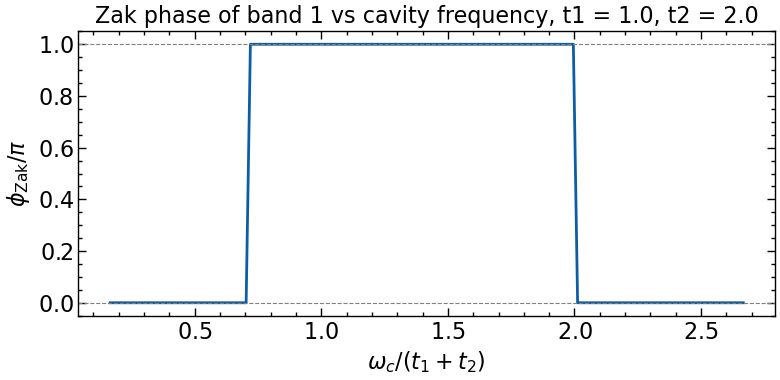

In [221]:
plt.figure(figsize=(8, 4))
plt.plot(omega_c_sweep/((t1+t2)), np.abs(np.array(zak_phases)) / np.pi)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel(r'$\omega_c / (t_1 + t_2)$')
plt.ylabel(r'$\phi_\mathrm{Zak} / \pi$')
plt.title(f'Zak phase of band {band} vs cavity frequency, t1 = 1.0, t2 = 2.0')
plt.tight_layout()
plt.show()

In [233]:
N = 100
N_photon = 8
t1 = 1.0
omega_c_values = np.array([0.5, 0.8, 1.8, 2.2]) * (t1 + t2)
g = 0.1
k_values = np.linspace(-np.pi, np.pi, N, endpoint=False)
t2 = 2.0
n_bands = 6

H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g, omega_c, k_index) 
            for k_index in range(N)]
           for omega_c in omega_c_values]

result_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=True) 
                 for H in H_omega]
                for H_omega in H_array]

energy_array = [[res[0] for res in row] for row in result_array]
state_array  = [[res[1] for res in row] for row in result_array]

photon_dm_array = [
    [
        [partial_trace(np.array(state_array[i][j][:, k]), N_photon, 2, keep='A')  # fix: 2 not 2*N
         for k in range(n_bands)]
        for j in range(len(k_values))
    ]
    for i in range(len(omega_c_values))
]

purity_array = np.array([
    [
        [np.einsum('ij,ji->', dm, dm).real for dm in dm_k]
        for dm_k in dm_omega
    ]
    for dm_omega in photon_dm_array
])  # shape: (n_omega, n_k, n_bands)

bare_H_array = [[k_block_ssh_cavity(N, N_photon, t1, t2, g=0, omega_c=omega_c, k_index=k_index)
                 for k_index in range(N)]
                for omega_c in omega_c_values]

bare_energy_array = [[eigsh(H, n_bands, which='SA', return_eigenvectors=False)
                      for H in H_omega]
                     for H_omega in bare_H_array]

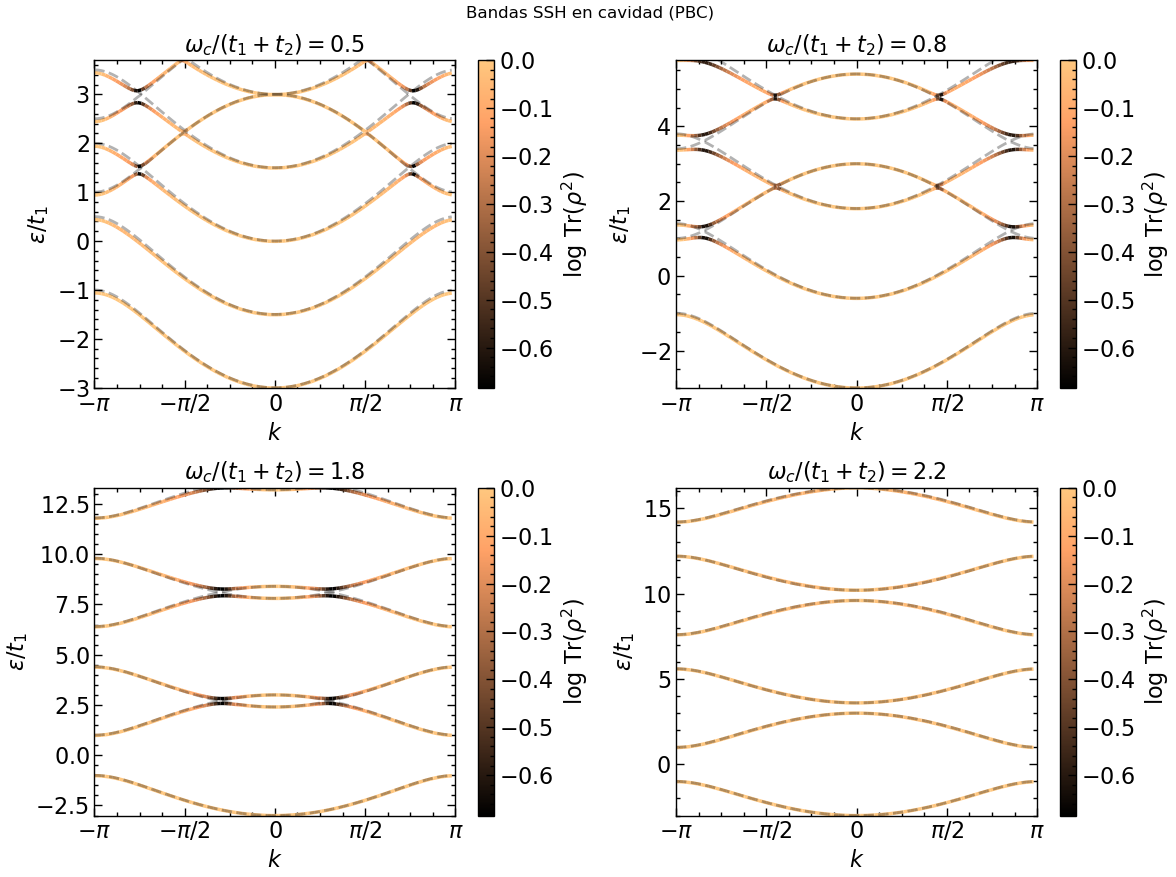

In [234]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
vmin = np.log(np.min(purity_array))

for i, (omega_c, ax) in enumerate(zip(omega_c_values, axes.flatten())):
    
    purity_omega_c = np.log(purity_array[i])
    energies_omega_c = np.array(energy_array[i])

    sorted_energies = np.zeros_like(energies_omega_c)
    sorted_purities = np.zeros_like(purity_omega_c)
    sorted_energies[0] = energies_omega_c[0]
    sorted_purities[0] = purity_omega_c[0]

    for ik in range(1, len(k_values)):
        prev = sorted_energies[ik - 1]
        curr = energies_omega_c[ik]
        order = []
        available = list(range(n_bands))
        for b in range(n_bands):
            diffs = [abs(curr[a] - prev[b]) for a in available]
            best = available[np.argmin(diffs)]
            order.append(best)
            available.remove(best)
        sorted_energies[ik] = curr[order]
        sorted_purities[ik] = purity_omega_c[ik][order]

    ax.set_title(rf'$\omega_c/(t_1+t_2) = {omega_c/(t1 + t2):.1f}$')
    norm = plt.Normalize(vmin=vmin, vmax=0.0)
    cmap = plt.cm.copper

    for band in range(n_bands):
        points = np.array([k_values, sorted_energies[:, band]]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.5)
        lc.set_array(sorted_purities[:, band])
        ax.add_collection(lc)

    ax.set_xlim(k_values.min(), k_values.max())
    ax.set_ylim(sorted_energies.min(), sorted_energies.max())
    if i == 0:
        ax.plot(k_values, bare_energy_array[i], linestyle = 'dashed', color = 'black', alpha = 0.3, label = 'Bare SSH')
    else:
        ax.plot(k_values, bare_energy_array[i], linestyle = 'dashed', color = 'black', alpha = 0.3)
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
    cbar.set_label(r'$\log\,\mathrm{Tr}(\rho^2)$')
    ax.set_xlabel(r'$k$')
    ax.set_ylabel(r'$\epsilon / t_1$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])

fig.suptitle('Bandas SSH en cavidad (PBC)')
fig.tight_layout()
plt.show()

In [245]:
k_values = np.fft.fftshift(2 * np.pi * np.fft.fftfreq(3))

In [246]:
k_values

array([-2.0943951,  0.       ,  2.0943951])